# Sunum Notu — Model Eğitimi, Değerlendirme ve Demo (V5)

## Araştırma sorusu (hatırlatma)

**Türkiye’de bir filmin gişe seyirci sayısı, vizyon öncesi gözlemlenebilir özelliklere dayanarak ne ölçüde tahmin edilebilir?**  
Bu not defteri yalnızca **model kararları**, **zaman temelli değerlendirme**, **çapraz doğrulama**, **özellik önemleri**, **artık analizi** ve **canlı demo** dosyalarının üretimine odaklanır; veri toplama ve EDA tekrar edilmez.

---

## Sunuma önerilen akış (~20 dk)

| Blok | Süre | Bu notebook’ta karşılığı |
|------|------|---------------------------|
| **Canlı demo** | ~5 dk | Son bölümde kaydedilen `demo/model.joblib` + `feature_names.json`; `python demo/demo_server.py` |
| **Model ve metrikler** | ~10 dk | Çoklu model tablosu, **seçilen model** (en yüksek test R²), fold bazlı CV, özellik önemleri |
| **Sonuç ve sorular** | ~5 dk | Artık grafikleri; güçlü/zayıf yönler ve sınırlılıklar (markdown) |

---

## Teknik özet

- **Veri:** `data/processed/ml_ready_dataset.csv` (ML-ready matris; detaylar önceki aşamada).
- **Hedef:** `Log_Toplam_Seyirci` — ham seyirci için `expm1` ile geri dönüşüm.
- **Bölünme:** `Liste_Yili ≤ 2022` eğitim, `≥ 2023` test — gelecek yılları simüle eden **zaman temelli** ayrım (rastgele bölünmeden daha gerçekçi dağılım kayması).
- **Eksik sayılar:** Yalnızca eğitim seti medyanı ile doldurulur (teste sızıntı yok).


## 1. Ortam ve veri dosyası

Aşağıdaki hücre kütüphaneleri yükler ve **yalnızca** ML-ready CSV’yi okur. Keşif grafikleri ve ham EDA bu sunum kapsamı dışındadır.


In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import joblib

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

PROJECT_ROOT = os.path.abspath('..')
DATA_PATH    = os.path.join(PROJECT_ROOT, 'data', 'processed', 'ml_ready_dataset.csv')
DEMO_DIR     = os.path.join(PROJECT_ROOT, 'demo')
os.makedirs(DEMO_DIR, exist_ok=True)

print(f'LightGBM {lgb.__version__}')
print(f'Data path: {DATA_PATH}')


LightGBM 4.6.0
Data path: c:\Users\furkan\Desktop\movie\data\processed\ml_ready_dataset.csv


In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

print(f'Shape          : {df.shape}')
print(f'Yıllar         : {df["Liste_Yili"].min()} – {df["Liste_Yili"].max()}')
print(f'Hedef (log)    : {df["Log_Toplam_Seyirci"].min():.2f} – {df["Log_Toplam_Seyirci"].max():.2f}')
print(f'Hedef (ham)    : {int(df["Toplam_Seyirci"].min()):,} – {int(df["Toplam_Seyirci"].max()):,} seyirci')
miss = df.isnull().sum()
miss = miss[miss > 0]
print(f'Eksik (adet)   : {miss.sum()} hücre')
if len(miss):
    print(miss.to_string())
print(f'\nYıla göre film :')
print(df['Liste_Yili'].value_counts().sort_index().to_string())


Shape          : (1976, 52)
Yıllar         : 2016 – 2025
Hedef (log)    : 3.66 – 15.82
Hedef (ham)    : 38 – 7,437,050 seyirci
Eksik (adet)   : 1469 hücre
Yonetmen            4
Oyuncular         337
Sure_Dakika         2
IMDb_Puani        101
Oyuncu1_Skor      337
Oyuncu2_Skor      337
Oyuncu3_Skor      350
Dagitimci_Skor      1

Yıla göre film :
Liste_Yili
2016    200
2017    200
2018    200
2019    200
2020    177
2021    199
2022    200
2023    200
2024    200
2025    200


## 2. Ön işleme ve zaman bazlı eğitim / test

Kimlik ve ham metin alanları (`Film_Adi`, `Yonetmen`, `Oyuncular`, …) **tahmin dışı** bırakılmıştır; `Tur_*`, mevsim, sıralı skorlar ve makro değişkenler modele girer. Eksik değerler **yalnızca eğitim medyanı** ile doldurulur; böylece test yılı için istatistik sızmaz.


In [3]:
# Kimlik / metin sütunları model girdisinde kullanılmaz
DROP_TEXT = ['Film_Linki', 'Film_Adi', 'Vizyon_Tarihi', 'Yonetmen', 'Oyuncular']
TARGET_LOG = 'Log_Toplam_Seyirci'
TARGET_RAW = 'Toplam_Seyirci'

df_sorted = df.sort_values('Liste_Yili').reset_index(drop=True)

train_mask = df_sorted['Liste_Yili'] <= 2022
train_df   = df_sorted[train_mask].copy()
test_df    = df_sorted[~train_mask].copy()
print(f'Zaman bölmesi: train={len(train_df)} (≤2022) | test={len(test_df)} (≥2023)')

feat_cols = [c for c in df_sorted.columns if c not in DROP_TEXT + [TARGET_RAW, TARGET_LOG]]

# Eğitim medyanı ile doldurma (sızıntıyı önlemek için sadece train istatistiği)
train_med = train_df[feat_cols].median()
train_df[feat_cols] = train_df[feat_cols].fillna(train_med)
test_df[feat_cols]  = test_df[feat_cols].fillna(train_med)

X_train = train_df[feat_cols]
X_test  = test_df[feat_cols]
y_train = train_df[TARGET_LOG].values
y_test  = test_df[TARGET_LOG].values
feature_names = feat_cols

print(f'Özellik sayısı: {len(feature_names)}')
print(f'X_train {X_train.shape} | X_test {X_test.shape}')


Zaman bölmesi: train=1376 (≤2022) | test=600 (≥2023)
Özellik sayısı: 45
X_train (1376, 45) | X_test (600, 45)


## 3. Model eğitimi ve sınaması

### Neden bu modeller?

| Model | Rol |
|--------|-----|
| **Ridge / Lasso** | Güçlü doğrusal taban çizgisi; ölçekli özelliklerde yorumlanabilir katsayı (burada zaman kayması nedeniyle testte zayıf kalabilir). |
| **Random Forest** | Göreli dayanıklılık, etkileşimleri yakalayan ilk ağaç topluluğu. |
| **Gradient Boosting (sklearn)** | Hata üzerinden ardışık düzeltme; sık kullanılan taban çizgisi. |
| **LightGBM** | Büyük özellik sayısında verimli yaprak tabanlı artırmalı öğrenme; demo ve çıkarım hızı için uygundur. |

**En iyi model seçimi:** Aşağıdaki tabloda **test R²** (zaman bölmesinde genelleme) birincil kriterdir; **Train − Test R²** (Overfit Gap) ikincil sinyaldir. Medyan mutlak yüzde hata (MedAPE) log-hedef üzerinden ham seyirciye çevrilerek raporlanır.

Not: Bu hücrenin sonunda, **en yüksek test R²** veren model `final_model` olarak atanır; CV, özellik önemleri (varsa), artıklar ve `model.joblib` bu seçimle uyumludur.


In [4]:
def medape(y_true, y_pred):
    # Ham ölçekte medyan mutlak yüzde hata
    return float(np.median(np.abs(np.exp(y_true) - np.exp(y_pred)) / np.exp(y_true)) * 100)


def evaluate(name, model, X_tr, X_te):
    p_tr = model.predict(X_tr)
    p_te = model.predict(X_te)
    return {
        'Model':        name,
        'Train R²':     round(float(r2_score(y_train, p_tr)), 4),
        'Test R²':      round(float(r2_score(y_test,  p_te)), 4),
        'Test MAE':     round(float(mean_absolute_error(y_test, p_te)), 4),
        'Test MedAPE%': round(medape(y_test, p_te), 2),
    }

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

results = []
print('Modeller eğitiliyor...\n')

ridge = Ridge(alpha=10.0)
ridge.fit(X_tr_sc, y_train)
results.append(evaluate('Ridge', ridge, X_tr_sc, X_te_sc))
print(f'  Ridge             Test R²={results[-1]["Test R²"]:.4f}')

lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_tr_sc, y_train)
results.append(evaluate('Lasso', lasso, X_tr_sc, X_te_sc))
print(f'  Lasso             Test R²={results[-1]["Test R²"]:.4f}')

rf = RandomForestRegressor(
    n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf.fit(X_train.values, y_train)
results.append(evaluate('Random Forest', rf, X_train.values, X_test.values))
print(f'  Random Forest     Test R²={results[-1]["Test R²"]:.4f}')

gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42
)
gbr.fit(X_train.values, y_train)
results.append(evaluate('GBR sklearn', gbr, X_train.values, X_test.values))
print(f'  GBR sklearn       Test R²={results[-1]["Test R²"]:.4f}')

lgbm = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=25,
    reg_alpha=0.05,
    reg_lambda=2.0,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
lgbm.fit(X_train.values, y_train)
best_iter = 300
results.append(evaluate('LightGBM (V5)', lgbm, X_train.values, X_test.values))
print(f'  LightGBM (V5)     Test R²={results[-1]["Test R²"]:.4f}')

df_res = pd.DataFrame(results)
df_res['Overfit Gap'] = (df_res['Train R²'] - df_res['Test R²']).round(4)

print('\n' + '=' * 72)
print(df_res.to_string(index=False))
print('=' * 72)

# --- Sunum / dışa aktarım modeli: tabloda en yüksek Test R² ---
best_row = df_res.loc[df_res['Test R²'].idxmax()]
best_model_name = best_row['Model']
_final_map = {
    'Ridge': ridge,
    'Lasso': lasso,
    'Random Forest': rf,
    'GBR sklearn': gbr,
    'LightGBM (V5)': lgbm,
}
final_model = _final_map[best_model_name]


def predict_final(X_arr):
    """X_arr: (n, p) numpy; Ridge/Lasso için eğitimdeki scaler uygulanır."""
    if best_model_name in ('Ridge', 'Lasso'):
        return final_model.predict(scaler.transform(X_arr))
    return final_model.predict(X_arr)


print(f'\n>>> Seçilen model (en yüksek Test R²): {best_model_name}')
print(f'    Test R² = {best_row["Test R²"]:.4f}  |  MedAPE % = {best_row["Test MedAPE%"]:.2f}')


Modeller eğitiliyor...

  Ridge             Test R²=-51.9608
  Lasso             Test R²=-34.7921
  Random Forest     Test R²=0.3115
  GBR sklearn       Test R²=0.4125
  LightGBM (V5)     Test R²=0.3676

        Model  Train R²  Test R²  Test MAE  Test MedAPE%  Overfit Gap
        Ridge    0.6590 -51.9608    9.4663    1491842.04      52.6198
        Lasso    0.6563 -34.7921    7.7654     254490.44      35.4484
Random Forest    0.7842   0.3115    0.9659         80.45       0.4727
  GBR sklearn    0.8366   0.4125    0.8876         70.42       0.4241
LightGBM (V5)    0.8908   0.3676    0.9089         74.11       0.5232

>>> Seçilen model (en yüksek Test R²): GBR sklearn
    Test R² = 0.4125  |  MedAPE % = 70.42


## 4. Görsel karşılaştırma (tüm adaylar)

Çubuk grafikleri sunumda **hangi modelin** testte öne çıktığını ve **aşırı öğrenme** izini (Train − Test R²) hızlı göstermek içindir.


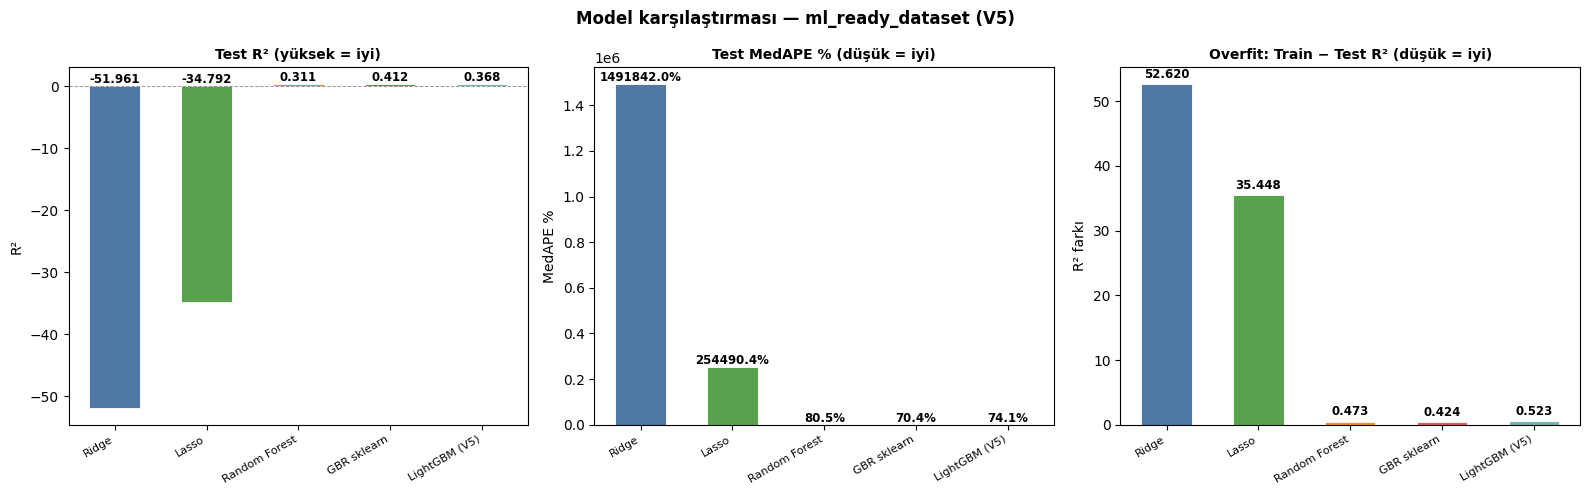

In [5]:
CMAP = {
    'Ridge':             '#4e79a7',
    'Lasso':             '#59a14f',
    'Random Forest':     '#f28e2b',
    'GBR sklearn':       '#e15759',
    'LightGBM (V5)':     '#76b7b2',
}
clr    = [CMAP.get(m, '#999999') for m in df_res['Model']]
labels = df_res['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model karşılaştırması — ml_ready_dataset (V5)', fontsize=12, fontweight='bold')

def annotated_bars(ax, x_labels, values, colors, title, ylabel):
    bars = ax.bar(x_labels, values, color=colors, width=0.55, edgecolor='white', linewidth=0.6)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    hi = max(values, default=1)
    for bar, v in zip(bars, values):
        ypos = max(float(bar.get_height()), 0) + max(abs(hi) * 0.01, 0.005)
        ax.text(bar.get_x() + bar.get_width() / 2, ypos, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

annotated_bars(axes[0], labels, df_res['Test R²'].tolist(), clr, 'Test R² (yüksek = iyi)', 'R²')

bars = axes[1].bar(labels, df_res['Test MedAPE%'].tolist(), color=clr,
                   width=0.55, edgecolor='white', linewidth=0.6)
axes[1].set_title('Test MedAPE % (düşük = iyi)', fontweight='bold', fontsize=10)
axes[1].set_ylabel('MedAPE %')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
for bar, v in zip(bars, df_res['Test MedAPE%'].tolist()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')

annotated_bars(axes[2], labels, df_res['Overfit Gap'].tolist(), clr,
               'Overfit: Train − Test R² (düşük = iyi)', 'R² farkı')

plt.tight_layout()
plt.show()


## 5. Zaman serisi çapraz doğrulama (fold bazlı)

**TimeSeriesSplit:** Eğitim seti zamana göre sıralı iken, her fold’da geçmiş daha büyük bir blokla eğitilip bir sonraki blok doğrulanır. Bu, **zaman temelli test bölmesi** ile uyumlu bir iç validasyon davranışı verir.

Aşağıdaki CV, **yukarıda seçilen `final_model`** ile aynı algoritma sınıfını (ve tablodaki ana boosting parametrelerini) kullanır; böylece “en iyi model” iddiası ile fold çıktıları çelişmez.


In [6]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

print(f'5 kat TimeSeriesSplit — {best_model_name}')
print('-' * 60)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    Xtr, Xva = X_train.values[tr_idx], X_train.values[val_idx]
    ytr, yva = y_train[tr_idx], y_train[val_idx]

    if best_model_name == 'Ridge':
        scv = StandardScaler()
        m = Ridge(alpha=10.0)
        m.fit(scv.fit_transform(Xtr), ytr)
        score = r2_score(yva, m.predict(scv.transform(Xva)))
    elif best_model_name == 'Lasso':
        scv = StandardScaler()
        m = Lasso(alpha=0.01, max_iter=5000)
        m.fit(scv.fit_transform(Xtr), ytr)
        score = r2_score(yva, m.predict(scv.transform(Xva)))
    elif best_model_name == 'Random Forest':
        m = RandomForestRegressor(
            n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1
        )
        m.fit(Xtr, ytr)
        score = r2_score(yva, m.predict(Xva))
    elif best_model_name == 'GBR sklearn':
        m = GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42
        )
        m.fit(Xtr, ytr)
        score = r2_score(yva, m.predict(Xva))
    else:
        m = lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=15,
            min_child_samples=25,
            reg_alpha=0.05,
            reg_lambda=2.0,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1,
        )
        m.fit(Xtr, ytr)
        score = r2_score(yva, m.predict(Xva))

    cv_scores.append(score)
    print(f'  Fold {fold + 1}: R² = {score:+.4f}  (train={len(tr_idx)} | val={len(val_idx)})')

cv_mean = float(np.mean(cv_scores))
cv_std = float(np.std(cv_scores))
print(f'\n  CV R² (mean ± std): {cv_mean:+.4f} ± {cv_std:.4f}')


5 kat TimeSeriesSplit — GBR sklearn
------------------------------------------------------------
  Fold 1: R² = +0.2652  (train=231 | val=229)
  Fold 2: R² = +0.4417  (train=460 | val=229)
  Fold 3: R² = +0.1799  (train=689 | val=229)
  Fold 4: R² = +0.4771  (train=918 | val=229)
  Fold 5: R² = -0.1779  (train=1147 | val=229)

  CV R² (mean ± std): +0.2372 ± 0.2348


## 6. Özellik önemleri (seçilen model)

Ağaç tabanlı modellerde **split/importance** (LightGBM/sklearn) veya benzeri önem ölçütü kullanılır. Sunumda şunu vurgulayın: önem, **nedensellik değil** — özellikler hedef ile korelasyonlu veya kofaktör olabilir.


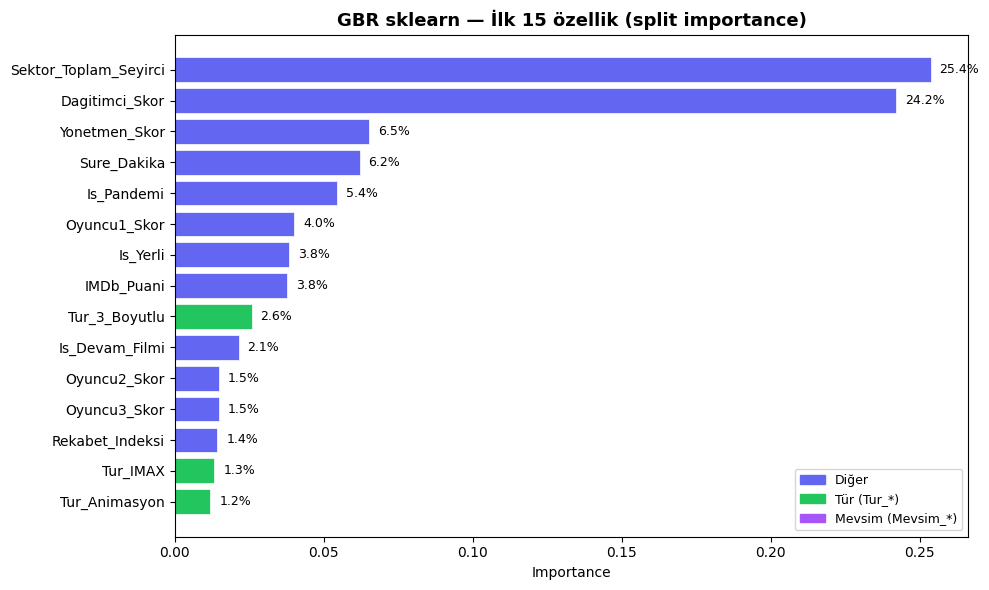

Liste_Yili importance           : 0.5%
Sektor_Toplam_Seyirci importance: 25.4%


In [7]:
if not hasattr(final_model, 'feature_importances_'):
    print(f'{best_model_name}: feature_importances_ yok (doğrusal model). Katsayı grafığı bu notta atlandı.')
    yr_imp = sektor_imp = 0.0
else:
    imp = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    top15 = imp.head(15)
    imp_sum = imp.sum()

    def feat_color(name):
        if name.startswith('Tur_'):
            return '#22c55e'
        if name.startswith('Mevsim_'):
            return '#a855f7'
        return '#6366f1'

    colors_fi = [feat_color(n) for n in top15.index]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(top15)), top15.values, color=colors_fi,
                   edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top15)))
    ax.set_yticklabels(top15.index, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f'{best_model_name} — İlk 15 özellik (split importance)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')

    for bar, val in zip(bars, top15.values):
        ax.text(bar.get_width() + imp_sum * 0.003,
                bar.get_y() + bar.get_height() / 2,
                f'{val / imp_sum * 100:.1f}%', va='center', fontsize=9)

    ax.legend(handles=[
        mpatches.Patch(color='#6366f1', label='Diğer'),
        mpatches.Patch(color='#22c55e', label='Tür (Tur_*)'),
        mpatches.Patch(color='#a855f7', label='Mevsim (Mevsim_*)'),
    ], loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.show()

    yr_imp = imp['Liste_Yili'] / imp_sum * 100 if 'Liste_Yili' in imp.index else 0.0
    sektor_imp = imp['Sektor_Toplam_Seyirci'] / imp_sum * 100 if 'Sektor_Toplam_Seyirci' in imp.index else 0.0
    print(f'Liste_Yili importance           : {yr_imp:.1f}%')
    print(f'Sektor_Toplam_Seyirci importance: {sektor_imp:.1f}%')


## 7. Artık analizi ve hata yapısı (test)

**Regresyonda “confusion matrix” yoktur** — sınıflandırma matrisi yerine **artık (gerçek − tahmin)** grafikleri ve dağılımı kullanılır. Konuşma sorularına hazırlık: yüksek tahmin / düşük tahmin kümeleri, uç değerler (çok yüksek seyircili filmler) ve log-dönüşümün artıklara etkisi.


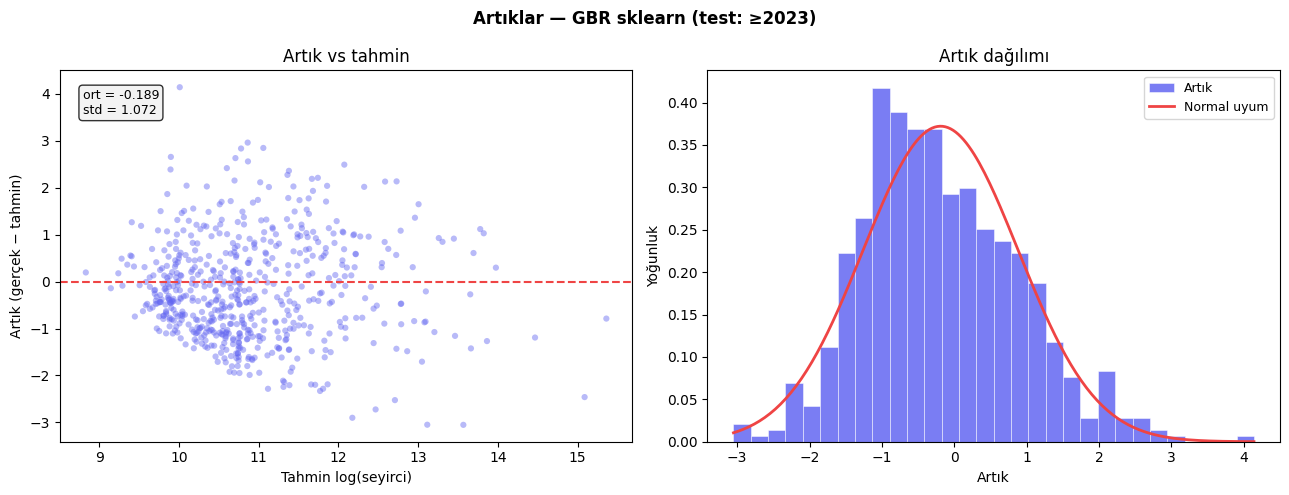

Artık ortalaması : -0.1885
Artık std        : 1.0721
Test MedAPE %    : 70.42%


In [8]:
y_pred = predict_final(X_test.values)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Artıklar — {best_model_name} (test: ≥2023)', fontsize=12, fontweight='bold')

ax = axes[0]
ax.scatter(y_pred, residuals, alpha=0.45, s=20, color='#6366f1', edgecolors='none')
ax.axhline(0, color='#ef4444', linewidth=1.5, linestyle='--', label='sıfır')
ax.set_xlabel('Tahmin log(seyirci)')
ax.set_ylabel('Artık (gerçek − tahmin)')
ax.set_title('Artık vs tahmin')
ax.text(0.04, 0.95,
        f'ort = {residuals.mean():.3f}\nstd = {residuals.std():.3f}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8), fontsize=9)

ax = axes[1]
ax.hist(residuals, bins=30, color='#6366f1', edgecolor='white',
        linewidth=0.4, density=True, alpha=0.85, label='Artık')
try:
    from scipy import stats as sp
    xs = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(xs, sp.norm.pdf(xs, residuals.mean(), residuals.std()),
            color='#ef4444', linewidth=2, label='Normal uyum')
except ImportError:
    pass
ax.set_title('Artık dağılımı')
ax.set_xlabel('Artık')
ax.set_ylabel('Yoğunluk')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

test_medape = medape(y_test, y_pred)
print(f'Artık ortalaması : {residuals.mean():.4f}')
print(f'Artık std        : {residuals.std():.4f}')
print(f'Test MedAPE %    : {test_medape:.2f}%')


## 8. Özet, sınırılıklar ve demo artefaktları

### Güçlü yönler
- Zaman bölmesi ile **gerçekçi** “geçmişten geleceğe” test.
- Çoklu model ve fold çıktısıyla **şeffaf** karşılaştırma.
- Özellik önemleri ile **yorumlanabilir** özet.

### Zayıf yönler ve riskler
- **Dağılım kayması:** Pandemi sonrası yıllar (2023+) eğitim dağılımından farklı olabilir; doğrusal modellerin çökmesi buna işaret eder.
- **Liste üst sınırı:** Kaynakta yıllık üst sıra kırpması — rekabet ve sektör toplamları **alt sınırlı** ölçülebilir.
- **Hedef log:** Büyük gişeleri sıkıştırır; uç kahramanlık filmlerinde hata oranı yüksek kalabilir.

### Canlı demo (5 dk)
1. Bu not defterindeki son kod hücresini çalıştırarak `demo/model.joblib` ve `feature_names.json` üretin.
2. Proje kökünden: `python demo/demo_server.py`
3. Tarayıcıda `demo/demo_ui.html` açıp farklı özellik kombinasyonları deneyin (`dist_encoding.json` bu pipeline’da kullanılmıyorsa backend’in beklediği girdi formatuna dikkat edin).

---
Aşağıdaki hücreler sayısal özeti yazdırır ve model dosyasını kaydeder.


In [9]:
print('=' * 65)
print('  ml_ready_dataset — V5 ÖZET (sunum)')
print('=' * 65)
print(f'\nVeri     : {len(df)} film | {df["Liste_Yili"].min()}–{df["Liste_Yili"].max()}')
print(f'Hedef    : Log_Toplam_Seyirci')
print(f'Özellik  : {len(feature_names)} (metin/kimlik çıkarıldı, medyan ile impute)')
print(f'Bölünme  : train ≤2022 ({len(train_df)}) | test ≥2023 ({len(test_df)})')

print('\n--- Tüm modeller (test) ---')
print(df_res[['Model', 'Train R²', 'Test R²', 'Test MedAPE%', 'Overfit Gap']].to_string(index=False))

print(f'\n--- Seçilen model: {best_model_name} ---')
print(f'  Test R²        : {best_row["Test R²"]:.4f}')
print(f'  Test MedAPE %  : {best_row["Test MedAPE%"]:.2f}')
print(f'  CV R² (mean±std): {cv_mean:+.4f} ± {cv_std:.4f}')
if hasattr(final_model, 'feature_importances_'):
    print(f'  Liste_Yili %   : {yr_imp:.1f}')
    print(f'  Sektor toplam %: {sektor_imp:.1f}')
print('=' * 65)


  ml_ready_dataset — V5 ÖZET (sunum)

Veri     : 1976 film | 2016–2025
Hedef    : Log_Toplam_Seyirci
Özellik  : 45 (metin/kimlik çıkarıldı, medyan ile impute)
Bölünme  : train ≤2022 (1376) | test ≥2023 (600)

--- Tüm modeller (test) ---
        Model  Train R²  Test R²  Test MedAPE%  Overfit Gap
        Ridge    0.6590 -51.9608    1491842.04      52.6198
        Lasso    0.6563 -34.7921     254490.44      35.4484
Random Forest    0.7842   0.3115         80.45       0.4727
  GBR sklearn    0.8366   0.4125         70.42       0.4241
LightGBM (V5)    0.8908   0.3676         74.11       0.5232

--- Seçilen model: GBR sklearn ---
  Test R²        : 0.4125
  Test MedAPE %  : 70.42
  CV R² (mean±std): +0.2372 ± 0.2348
  Liste_Yili %   : 0.5
  Sektor toplam %: 25.4


In [10]:
from sklearn.pipeline import make_pipeline

model_path = os.path.join(DEMO_DIR, 'model.joblib')
if best_model_name == 'Ridge':
    export_model = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
elif best_model_name == 'Lasso':
    export_model = make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=5000))
else:
    export_model = final_model

if best_model_name in ('Ridge', 'Lasso'):
    export_model.fit(X_train, y_train)

joblib.dump(export_model, model_path)
print(f'Kaydedildi: model.joblib  -> {model_path}  ({best_model_name})')

feat_path = os.path.join(DEMO_DIR, 'feature_names.json')
with open(feat_path, 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)
print(f'Kaydedildi: feature_names.json -> {feat_path} ({len(feature_names)} ozellik)')

metrics_path = os.path.join(DEMO_DIR, 'model_metrics.json')
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'model_name': f'{best_model_name} (V5)',
            'metric1_label': 'Test R² (temporal, ≥2023)',
            'metric1_value': f"{best_row['Test R²']:.4f}",
            'metric2_label': 'Test MedAPE',
            'metric2_value': f"{best_row['Test MedAPE%']:.2f}%",
            'training_note': f'Eğitim: ≤2022 ({len(train_df)} film) | Test: ≥2023 ({len(test_df)})',
        },
        f,
        ensure_ascii=False,
        indent=2,
    )
print(f'Kaydedildi: model_metrics.json -> {metrics_path} (demo UI / sunucu okur)')

print('\nDemo: proje kokunden  python demo/demo_server.py')
print('Sunucuyu her model export sonrasi yeniden baslatin; model_metrics.json guncellenir.')


Kaydedildi: model.joblib  -> c:\Users\furkan\Desktop\movie\demo\model.joblib  (GBR sklearn)
Kaydedildi: feature_names.json -> c:\Users\furkan\Desktop\movie\demo\feature_names.json (45 ozellik)

Demo: proje kokunden  python demo/demo_server.py
Not: demo_ui.html girdileri bu pipeline ile birebir ayni olmayabilir; gerekirse demo ucu bu JSON sutun sirasina gore guncellenir.
